# Supplementary Figure S1 — Characterization of PARSE–DSSR disagreements across Leontis–Westhof classes

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.ticker import FixedLocator, FuncFormatter

_ROOT = Path.cwd().parent.parent
_SUB = "supplemental" if Path.cwd().name == "supplemental_figures" else "main"
FIGURES = _ROOT / "figures" / _SUB

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / _SUB / name

## (A) Composition of PARSE–DSSR disagreements by LW class

saved figures/supplemental/figS1_A_disagreement_composition.png


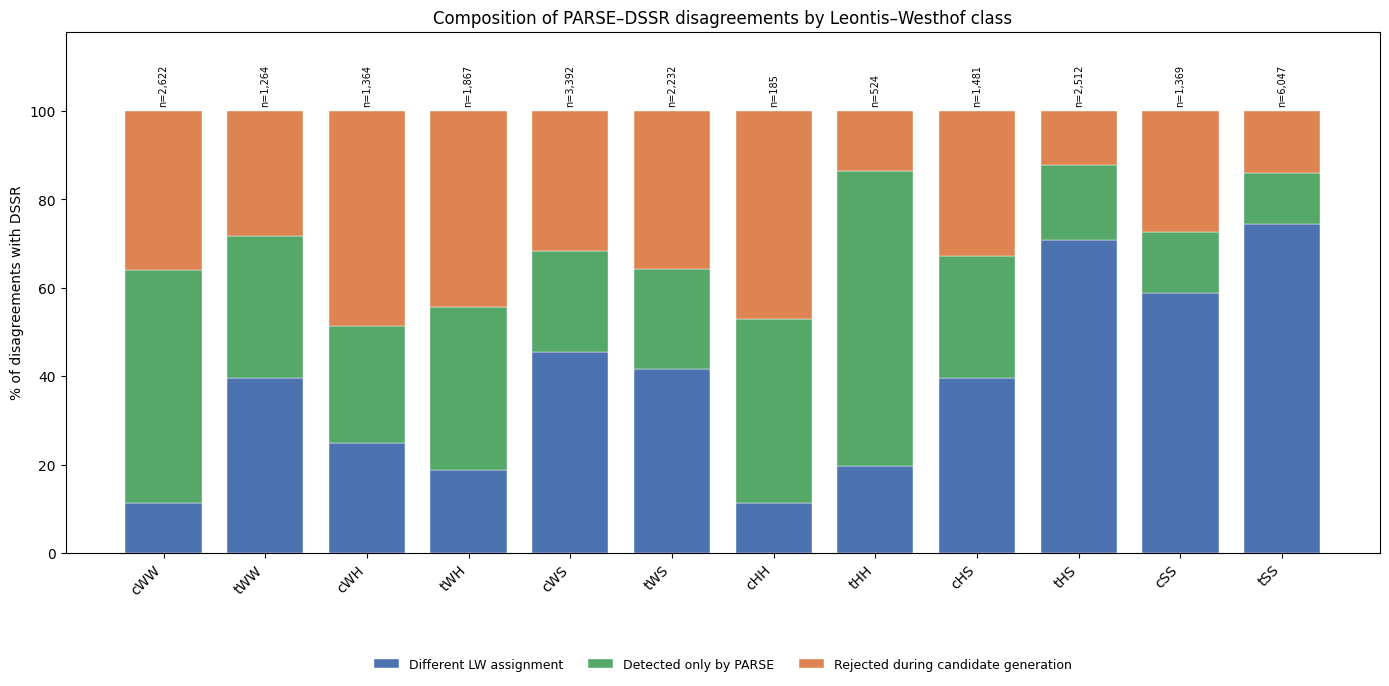

In [2]:
# comparison JSONs (one per LW class), flat in data/comparison/
NONCWW_ORDER = ["tWW", "cWH", "tWH", "cWS", "tWS", "cHH", "tHH", "cHS", "tHS", "cSS", "tSS"]
cww_data = json.load(open(data_file("comparison/cWW.json")))
noncww = {lw: json.load(open(data_file(f"comparison/{lw}.json"))) for lw in NONCWW_ORDER}
diffs_by_class = {"cWW": cww_data["differences"]}
diffs_by_class.update({c: noncww[c]["differences"] for c in NONCWW_ORDER})
REASON_CLS = ["cWW"] + NONCWW_ORDER

def _reason_bucket(e):
    r = e.get("reason") or ""
    if r.startswith("python_assigns:"):
        return None                 # misclassified = mirror of a class-disagree; drop
    if r.startswith("dssr_assigns:"):
        return "class-disagree"     # our pair; DSSR labels it a different class
    return r                        # not_candidate / failed_validation / novel / unknown

def _dssr_ambiguous(e):
    r = e.get("reason") or ""
    if r.startswith("dssr_assigns:") and "." in r.split(":", 1)[1]:
        return True
    return "." in (e.get("dssr_lw_class") or "")

ALL_ORDER = ["class-disagree", "novel", "not_candidate", "failed_validation", "unknown"]
ALL_COL = {"class-disagree": "#4C72B0", "novel": "#55A868",
           "not_candidate": "#DD8452", "failed_validation": "#C44E52", "unknown": "#B0B0B0"}
LABEL = {"class-disagree": "Different LW assignment",
         "novel": "Detected only by PARSE",
         "not_candidate": "Rejected during candidate generation",
         "failed_validation": "Failed validation", "unknown": "Other"}
EXCLUDE_REASONS = {"not_selected", "low_score", "no_strong_hbond", "stacking", "adjacent"}

allr, n_excl = {}, {}
for c in REASON_CLS:
    n_excl[c] = sum(1 for e in diffs_by_class[c] if _dssr_ambiguous(e))
    kept = [e for e in diffs_by_class[c]
            if not _dssr_ambiguous(e) and (e.get("reason") or "") not in EXCLUDE_REASONS]
    allr[c] = Counter(b for e in kept if (b := _reason_bucket(e)) is not None)

xx = np.arange(len(REASON_CLS))
totals = [sum(allr[c].values()) for c in REASON_CLS]
ALL_ORDER = [rb for rb in ALL_ORDER if sum(allr[c].get(rb, 0) for c in REASON_CLS) > 0]

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(REASON_CLS))
for rb in ALL_ORDER:
    vals = np.array([100 * allr[c].get(rb, 0) / max(totals[i], 1) for i, c in enumerate(REASON_CLS)])
    ax.bar(xx, vals, bottom=bottom, color=ALL_COL[rb], width=0.75,
           edgecolor="white", lw=0.3, label=LABEL[rb])
    bottom += vals
for i, t in enumerate(totals):
    ax.text(i, 101, f"n={t:,}", ha="center", va="bottom", fontsize=7, rotation=90)
ax.set_xticks(xx); ax.set_xticklabels(REASON_CLS, rotation=45, ha="right")
ax.set_ylim(0, 118); ax.set_ylabel("% of disagreements with DSSR")
ax.set_title("Composition of PARSE–DSSR disagreements by Leontis–Westhof class")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=len(ALL_ORDER),
          fontsize=9, frameon=False)
fig.tight_layout()
print("saved", savefig(fig, "figS1_A_disagreement_composition.png"))
plt.show()